1. What is unsupervised learning in the context of machine learning?
* Unsupervised learning is a type of machine learning where the model finds patterns or structures in data without using labeled outputs.

2. How does K-Means clustering algorithm work?
* K-Means clustering partitions data into *K* clusters by assigning each point to the nearest centroid and then updating centroids based on the mean of assigned points.
This process repeats iteratively until the centroids stabilize or a stopping criterion is met.

3. Explain the concept of a dendrogram in hierarchical clustering.
* A dendrogram is a tree-like diagram that visualizes the arrangement of clusters formed by hierarchical clustering. It shows how individual data points merge into clusters step-by-step based on similarity or distance.

4.  What is the main difference between K-Means and Hierarchical Clustering?
* The main difference is that K-Means requires specifying the number of clusters in advance, while Hierarchical Clustering builds a tree of clusters without needing to predefine the number.

5. What are the advantages of DBSCAN over K-Means?
*
- Does not require specifying the number of clusters in advance

- Can find arbitrarily shaped clusters

- Handles noise and outliers effectively

- Works well with clusters of varying densities

6. When would you use Silhouette Score in clustering?
* Silhouette Score is used to evaluate the quality of clustering by measuring how similar a point is to its own cluster compared to other clusters, helping to determine the optimal number of clusters.

7.  What are the limitations of Hierarchical Clustering?
*
- Not suitable for large datasets due to high time and space complexity
- Sensitive to noise and outliers
- Once a merge or split is done, it cannot be undone
- Choosing the right linkage method can significantly affect results

8. Why is feature scaling important in clustering algorithms like K-Means?
* Feature scaling is important in clustering algorithms like K-Means because it ensures that all features contribute equally to distance calculations, preventing features with larger ranges from dominating the clustering process.

9. How does DBSCAN identify noise points?
* DBSCAN identifies noise points as those that do not have enough neighboring points within a specified radius (ε) to be considered part of a cluster and are not reachable from any core point.

10. Define inertia in the context of K-Means.
* Inertia in K-Means is the sum of squared distances between each data point and the centroid of its assigned cluster, representing how compact the clusters are.

11. What is the elbow method in K-Means clustering?
* The elbow method in K-Means clustering is a technique to determine the optimal number of clusters by plotting the inertia against the number of clusters and identifying the point where the rate of decrease sharply changes, forming an "elbow."

12. Describe the concept of "density" in DBSCAN.
* In DBSCAN, "density" refers to the number of data points within a specified radius (ε) around a point; a region is considered dense if it contains at least a minimum number of points (MinPts), allowing the algorithm to form clusters based on areas of high point concentration.

13. Can hierarchical clustering be used on categorical data?
* Yes, hierarchical clustering can be used on categorical data, but it requires the use of appropriate distance measures, such as the **Jaccard index** or **Hamming distance**, instead of traditional distance metrics like Euclidean distance.

14. What does a negative Silhouette Score indicate?
* A negative Silhouette Score indicates that the data points are likely misclassified, as they are closer to points in other clusters than to points in their own cluster, suggesting poor clustering results.

15. Explain the term "linkage criteria" in hierarchical clustering.
* "Linkage criteria" in hierarchical clustering define how the distance between clusters is calculated when merging them. Common linkage methods include **single linkage** (minimum distance), **complete linkage** (maximum distance), and **average linkage** (average distance between all points in the clusters).

16. Why might K-Means clustering perform poorly on data with varying cluster sizes or densities?
* K-Means clustering may perform poorly on data with varying cluster sizes or densities because it assumes spherical, equally sized clusters. It struggles to accurately capture irregular shapes or clusters with different densities, as the algorithm relies on the distance from centroids, which doesn't work well in such cases.

17. What are the core parameters in DBSCAN, and how do they influence clustering?
* The core parameters in DBSCAN are **ε (epsilon)** and **MinPts**.

* ε (epsilon) defines the maximum distance between two points for them to be considered neighbors. A smaller ε can lead to more clusters and potential noise points, while a larger ε may merge distinct clusters.
* MinPts specifies the minimum number of points required to form a dense region (cluster). Increasing MinPts makes the algorithm more selective about what constitutes a cluster, potentially resulting in more noise points.

18. How does K-Means++ improve upon standard K-Means initialization?
* K-Means++ improves upon standard K-Means initialization by selecting the initial centroids in a way that spreads them out. It starts by choosing the first centroid randomly, then selects each subsequent centroid based on the distance from the existing centroids, giving higher probability to points farther away. This helps reduce the likelihood of poor initial centroids and leads to faster convergence and better clustering results.

19. What is agglomerative clustering?
* Agglomerative clustering is a type of hierarchical clustering that starts with each data point as its own cluster and iteratively merges the closest clusters based on a defined distance metric until all points are grouped into a single cluster. It is a bottom-up approach, in contrast to divisive clustering, which starts with all points in one cluster and splits them.

20. What makes Silhouette Score a better metric than just inertia for model evaluation?
* Silhouette Score is a better metric than inertia for model evaluation because it considers both the compactness of clusters (how close points are to their own cluster) and the separation between clusters (how far apart clusters are from each other). In contrast, inertia only measures the compactness of clusters, without accounting for how well-separated the clusters are, which can lead to misleading results, especially when clusters are not well-separated.








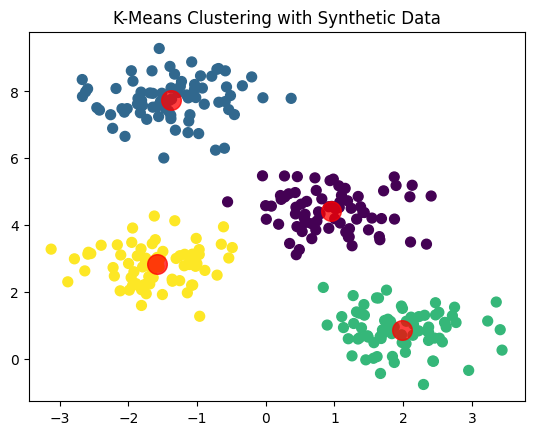

In [1]:
#Question 21

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

X, y = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)
kmeans = KMeans(n_clusters=4)
y_kmeans = kmeans.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.75)
plt.title('K-Means Clustering with Synthetic Data')
plt.show()

In [3]:
#Question 22

import numpy as np
from sklearn.datasets import load_iris
from sklearn.cluster import AgglomerativeClustering

iris = load_iris()
X = iris.data
agg = AgglomerativeClustering(n_clusters=3)
labels = agg.fit_predict(X)
print(labels[:10])





[1 1 1 1 1 1 1 1 1 1]


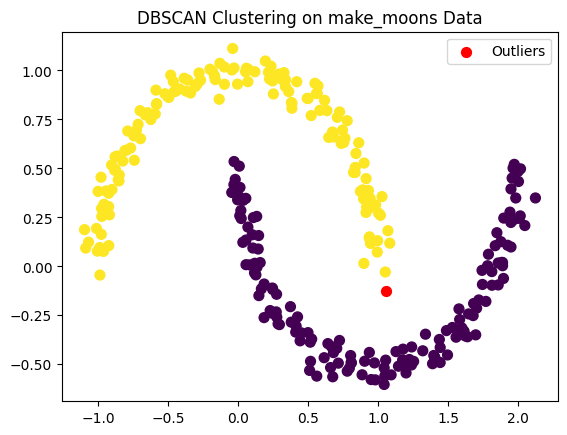

In [4]:
#Question 23
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
import numpy as np

X, y = make_moons(n_samples=300, noise=0.05, random_state=0)
dbscan = DBSCAN(eps=0.15, min_samples=5)
labels = dbscan.fit_predict(X)

outliers = labels == -1
plt.scatter(X[labels != -1, 0], X[labels != -1, 1], c=labels[labels != -1], cmap='viridis', s=50)
plt.scatter(X[outliers, 0], X[outliers, 1], c='red', s=50, label='Outliers')
plt.legend()
plt.title('DBSCAN Clustering on make_moons Data')
plt.show()


In [5]:
#Question 24
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np

wine = load_wine()
X = wine.data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
kmeans = KMeans(n_clusters=3, random_state=0)
labels = kmeans.fit_predict(X_scaled)
unique, counts = np.unique(labels, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"Cluster {cluster}: {count} samples")

Cluster 0: 65 samples
Cluster 1: 51 samples
Cluster 2: 62 samples


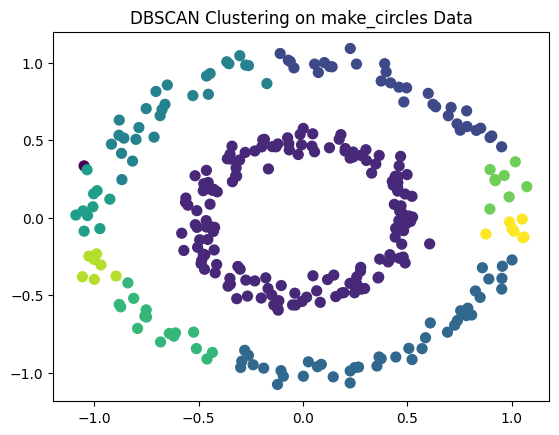

In [6]:
#Question 25
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.cluster import DBSCAN

X, y = make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=0)
dbscan = DBSCAN(eps=0.15, min_samples=5)
labels = dbscan.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50)
plt.title("DBSCAN Clustering on make_circles Data")
plt.show()


In [7]:
#Question 26
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

data = load_breast_cancer()
X = data.data
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
kmeans = KMeans(n_clusters=2, random_state=0)
kmeans.fit(X_scaled)
print(kmeans.cluster_centers_)


[[0.25535358 0.28833455 0.24696416 0.14388369 0.35743076 0.18019471
  0.10344776 0.1306603  0.34011829 0.25591606 0.06427485 0.18843043
  0.05975663 0.02870108 0.18158628 0.13242941 0.05821528 0.18069336
  0.17221057 0.08403996 0.2052406  0.32069002 0.19242138 0.09943446
  0.3571115  0.14873935 0.13142287 0.26231363 0.22639412 0.15437354]
 [0.50483563 0.39560329 0.50578661 0.36376576 0.46988732 0.42226302
  0.41838662 0.46928035 0.45899738 0.29945886 0.19093085 0.19112073
  0.17903433 0.13086432 0.18017962 0.25890126 0.12542475 0.30942779
  0.190072   0.13266975 0.48047448 0.45107371 0.4655302  0.31460597
  0.49868817 0.36391461 0.39027292 0.65827197 0.33752296 0.26041387]]


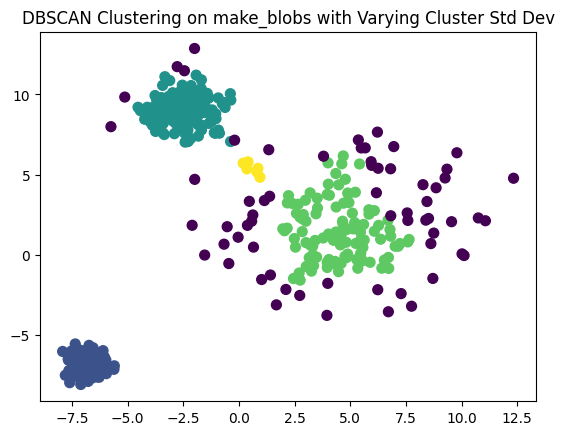

In [8]:
#Question 27
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import DBSCAN

X, y = make_blobs(n_samples=500, centers=3, cluster_std=[1.0, 2.5, 0.5], random_state=42)
dbscan = DBSCAN(eps=0.8, min_samples=5)
labels = dbscan.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50)
plt.title("DBSCAN Clustering on make_blobs with Varying Cluster Std Dev")
plt.show()


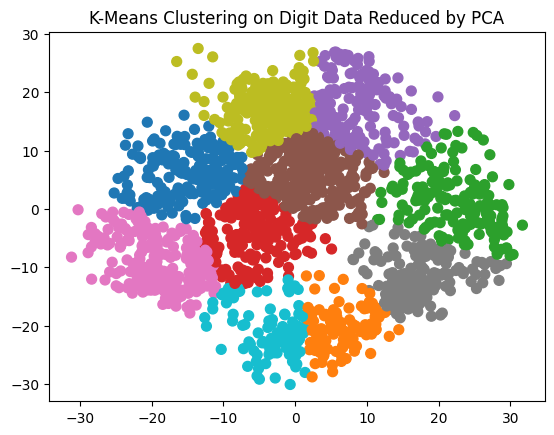

In [9]:
#Question 28
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

digits = load_digits()
X = digits.data
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
kmeans = KMeans(n_clusters=10, random_state=0)
labels = kmeans.fit_predict(X_pca)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10', s=50)
plt.title("K-Means Clustering on Digit Data Reduced by PCA")
plt.show()


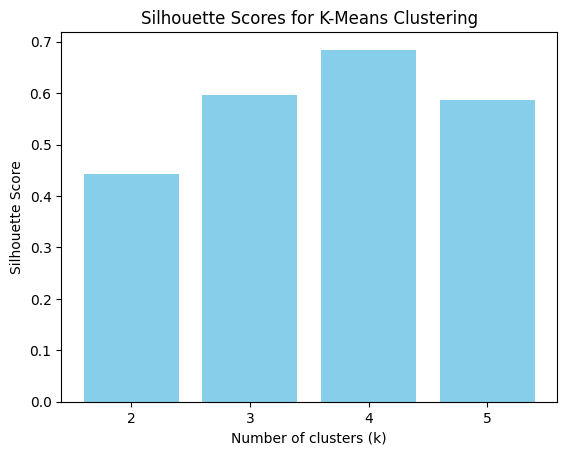

In [10]:
#Question 29

import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X, _ = make_blobs(n_samples=500, centers=4, cluster_std=0.60, random_state=0)
sil_scores = []
k_values = range(2, 6)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=0)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    sil_scores.append(score)

plt.bar(k_values, sil_scores, color='skyblue')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores for K-Means Clustering')
plt.xticks(k_values)
plt.show()

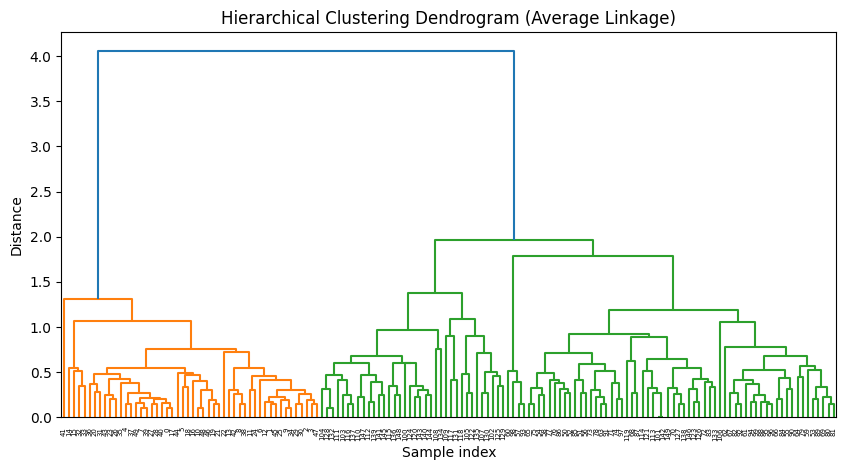

In [11]:
#Question 30
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from scipy.cluster.hierarchy import dendrogram, linkage

iris = load_iris()
X = iris.data

Z = linkage(X, method='average')

plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title('Hierarchical Clustering Dendrogram (Average Linkage)')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.show()


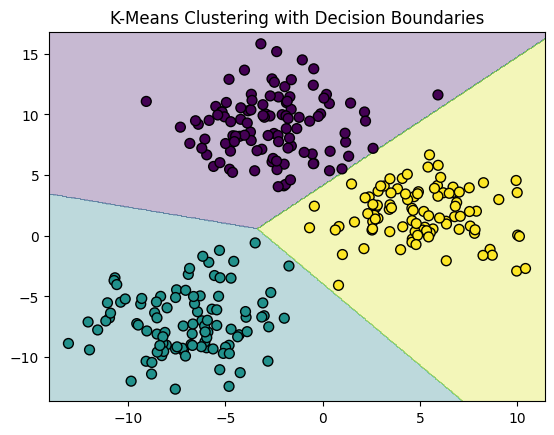

In [12]:
#Question 31
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

X, y = make_blobs(n_samples=300, centers=3, cluster_std=2.5, random_state=42)
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))
Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis', edgecolor='k')
plt.title('K-Means Clustering with Decision Boundaries')
plt.show()


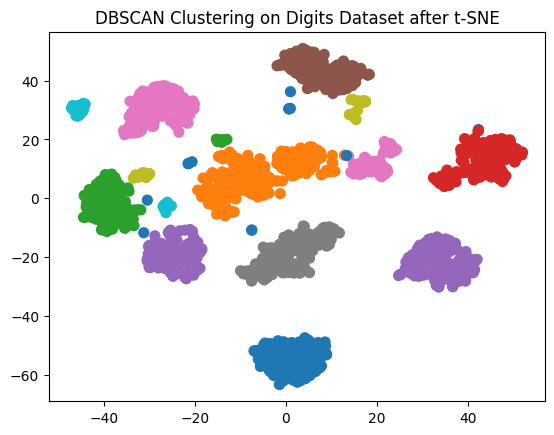

In [13]:
#Question 32
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN

digits = load_digits()
X = digits.data
tsne = TSNE(n_components=2, random_state=0)
X_tsne = tsne.fit_transform(X)
dbscan = DBSCAN(eps=3, min_samples=5)
labels = dbscan.fit_predict(X_tsne)

plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='tab10', s=50)
plt.title("DBSCAN Clustering on Digits Dataset after t-SNE")
plt.show()


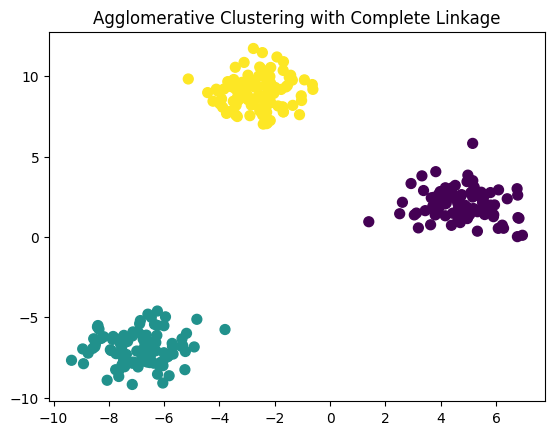

In [14]:
#Question 33
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering

X, y = make_blobs(n_samples=300, centers=3, cluster_std=1.0, random_state=42)
agg = AgglomerativeClustering(n_clusters=3, linkage='complete')
labels = agg.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50)
plt.title('Agglomerative Clustering with Complete Linkage')
plt.show()


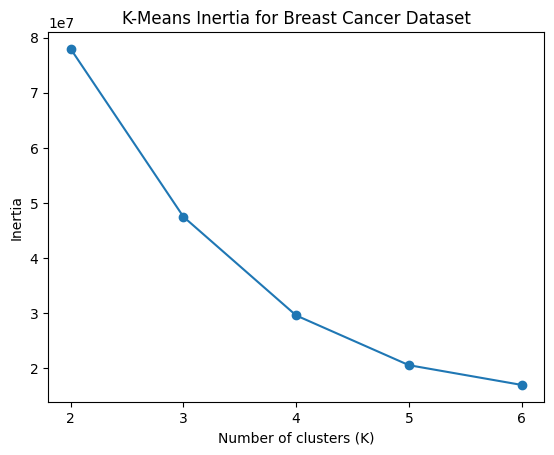

In [15]:
#Question 34
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.cluster import KMeans

data = load_breast_cancer()
X = data.data
inertias = []
k_values = range(2, 7)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

plt.plot(k_values, inertias, marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.title('K-Means Inertia for Breast Cancer Dataset')
plt.xticks(k_values)
plt.show()


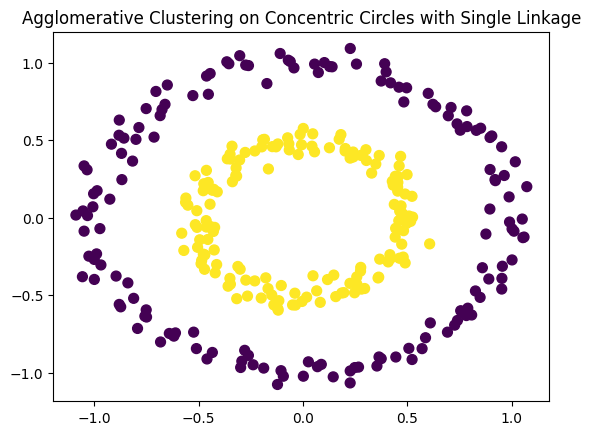

In [16]:
#Question 35
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.cluster import AgglomerativeClustering

X, y = make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=0)
agg = AgglomerativeClustering(n_clusters=2, linkage='single')
labels = agg.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50)
plt.title('Agglomerative Clustering on Concentric Circles with Single Linkage')
plt.show()


In [17]:
#Question 36
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import numpy as np

wine = load_wine()
X = wine.data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

dbscan = DBSCAN(eps=0.9, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

num_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(f'Number of clusters (excluding noise): {num_clusters}')


Number of clusters (excluding noise): 0


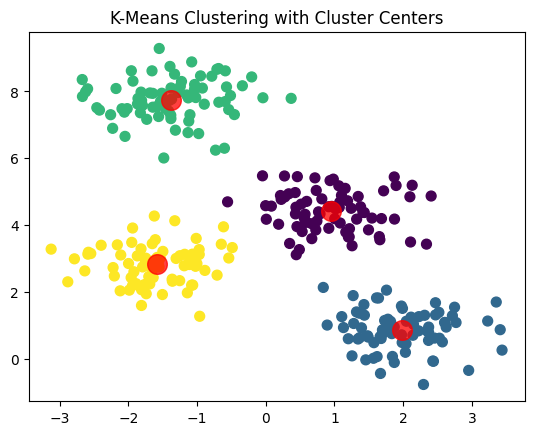

In [18]:
#Question 37
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

X, y = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)
kmeans = KMeans(n_clusters=4, random_state=0)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.75)
plt.title("K-Means Clustering with Cluster Centers")
plt.show()


In [19]:
#Question 38
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

iris = load_iris()
X = iris.data
X = StandardScaler().fit_transform(X)

db = DBSCAN(eps=0.5, min_samples=5).fit(X)
labels = db.labels_

n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)


Estimated number of clusters: 2
Estimated number of noise points: 34


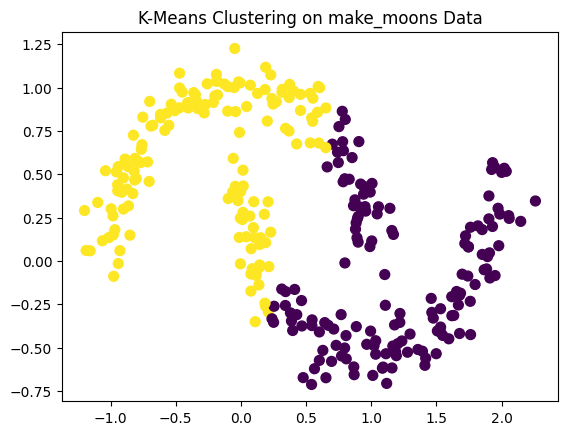

In [20]:
#Question 39
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans

X, y = make_moons(n_samples=300, noise=0.1, random_state=0)
kmeans = KMeans(n_clusters=2, random_state=0)
labels = kmeans.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50)
plt.title("K-Means Clustering on make_moons Data")
plt.show()


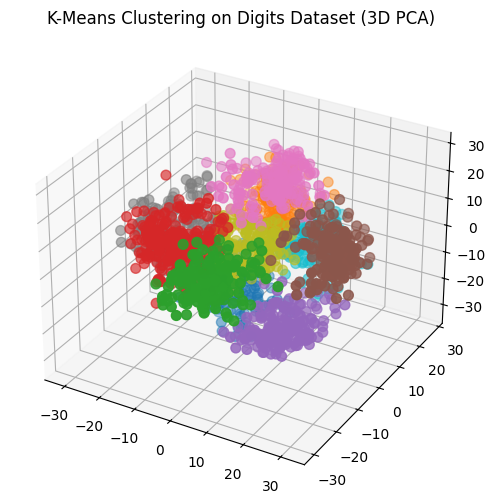

In [21]:
#Question 40
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

digits = load_digits()
X = digits.data
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)
kmeans = KMeans(n_clusters=10, random_state=0)
labels = kmeans.fit_predict(X_pca)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels, cmap='tab10', s=50)
ax.set_title('K-Means Clustering on Digits Dataset (3D PCA)')
plt.show()


In [22]:
#Question 41
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X, y = make_blobs(n_samples=500, centers=5, cluster_std=0.60, random_state=0)
kmeans = KMeans(n_clusters=5, random_state=0)
labels = kmeans.fit_predict(X)
score = silhouette_score(X, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.7173642175642293


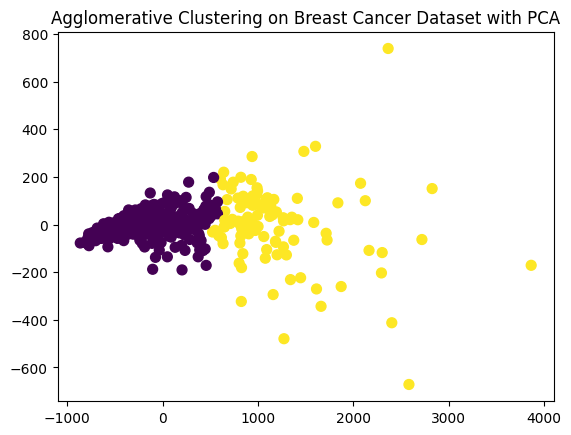

In [23]:
#Question 42
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering

data = load_breast_cancer()
X = data.data
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
agg = AgglomerativeClustering(n_clusters=2)
labels = agg.fit_predict(X_pca)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=50)
plt.title("Agglomerative Clustering on Breast Cancer Dataset with PCA")
plt.show()

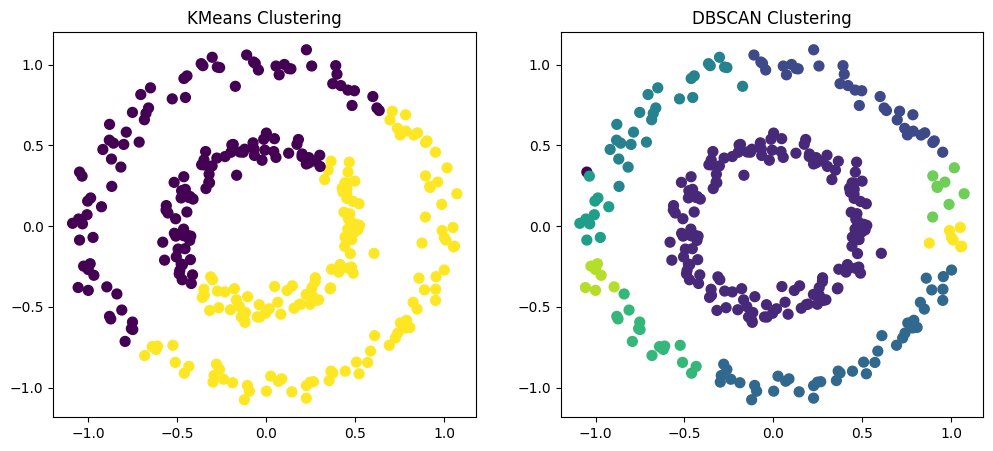

In [24]:
#Question 43
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.cluster import KMeans, DBSCAN

X, y = make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=0)
kmeans = KMeans(n_clusters=2, random_state=0)
labels_kmeans = kmeans.fit_predict(X)
dbscan = DBSCAN(eps=0.15, min_samples=5)
labels_dbscan = dbscan.fit_predict(X)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].scatter(X[:, 0], X[:, 1], c=labels_kmeans, cmap='viridis', s=50)
axs[0].set_title('KMeans Clustering')

axs[1].scatter(X[:, 0], X[:, 1], c=labels_dbscan, cmap='viridis', s=50)
axs[1].set_title('DBSCAN Clustering')

plt.show()

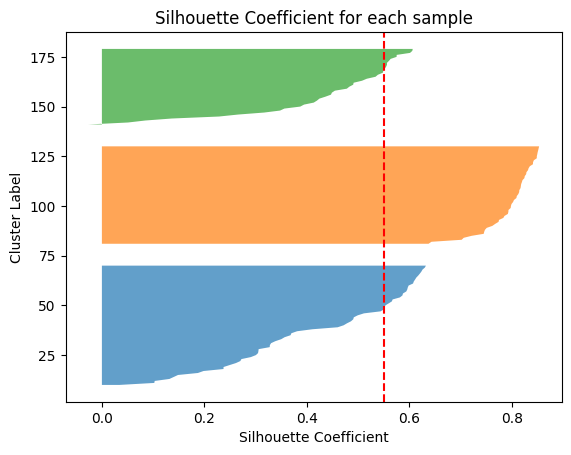

In [25]:
#Question 44
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

iris = load_iris()
X = iris.data
kmeans = KMeans(n_clusters=3, random_state=0)
labels = kmeans.fit_predict(X)

silhouette_vals = silhouette_samples(X, labels)
y_lower = 10

for i in range(3):
    ith_cluster_silhouette_values = silhouette_vals[labels == i]
    ith_cluster_silhouette_values.sort()
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i
    plt.fill_betweenx(np.arange(y_lower, y_upper), ith_cluster_silhouette_values, alpha=0.7)
    y_lower = y_upper + 10

plt.title('Silhouette Coefficient for each sample')
plt.xlabel('Silhouette Coefficient')
plt.ylabel('Cluster Label')
plt.axvline(x=silhouette_score(X, labels), color='red', linestyle='--')
plt.show()


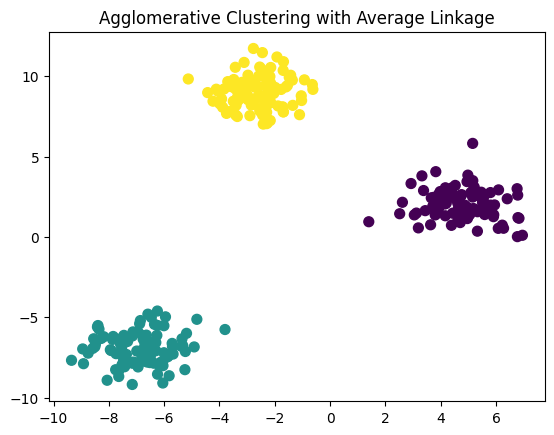

In [26]:
#Question 45
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering

X, y = make_blobs(n_samples=300, centers=3, cluster_std=1.0, random_state=42)
agg = AgglomerativeClustering(n_clusters=3, linkage='average')
labels = agg.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50)
plt.title('Agglomerative Clustering with Average Linkage')
plt.show()


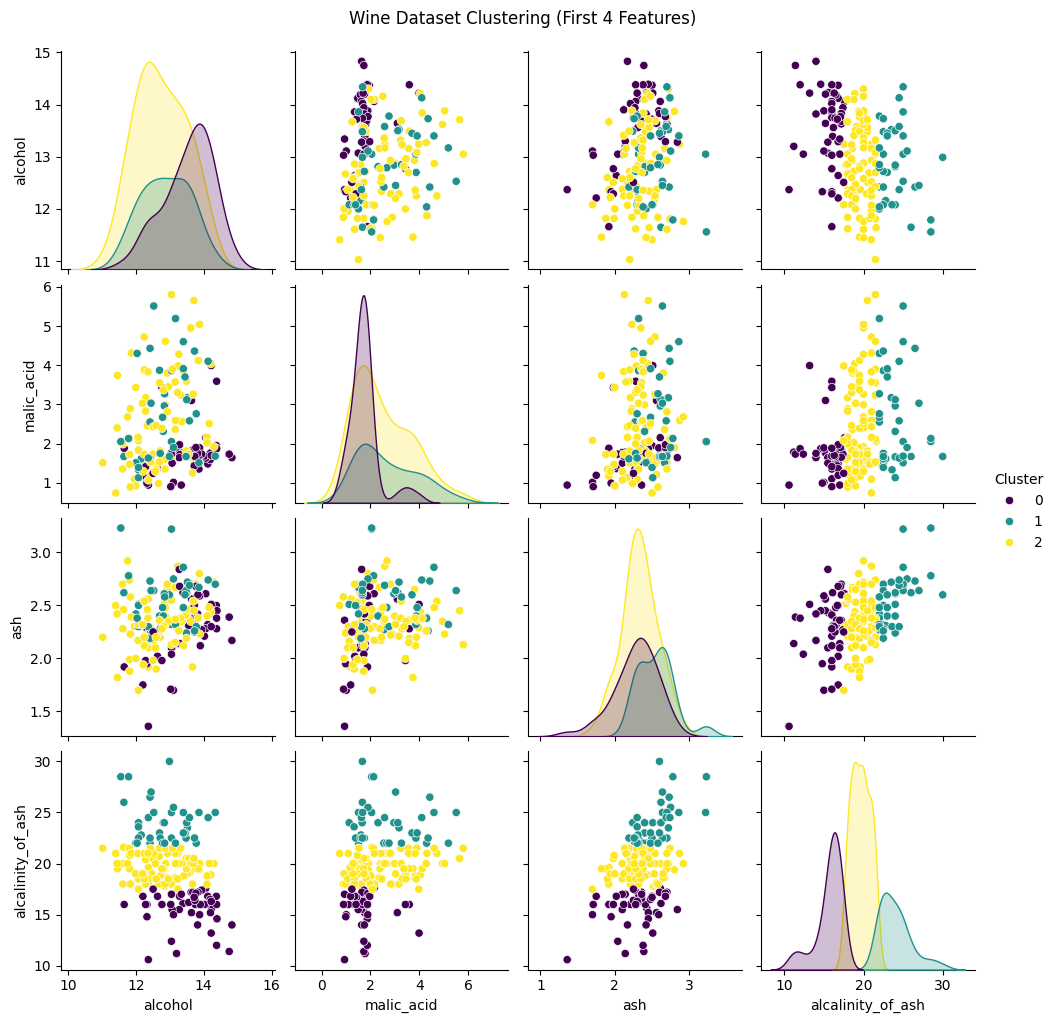

In [27]:
#Question 46
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.cluster import KMeans

wine = load_wine()
X = wine.data[:, :4]
kmeans = KMeans(n_clusters=3, random_state=0)
labels = kmeans.fit_predict(X)

df = pd.DataFrame(X, columns=wine.feature_names[:4])
df['Cluster'] = labels

sns.pairplot(df, hue='Cluster', palette='viridis')
plt.suptitle("Wine Dataset Clustering (First 4 Features)", y=1.02)
plt.show()

In [28]:
#Question 47
from sklearn.datasets import make_blobs
from sklearn.cluster import DBSCAN
import numpy as np

X, y = make_blobs(n_samples=300, centers=3, cluster_std=1.5, random_state=0)
dbscan = DBSCAN(eps=0.8, min_samples=5)
labels = dbscan.fit_predict(X)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f'Number of clusters: {n_clusters}')
print(f'Number of noise points: {n_noise}')

Number of clusters: 2
Number of noise points: 23


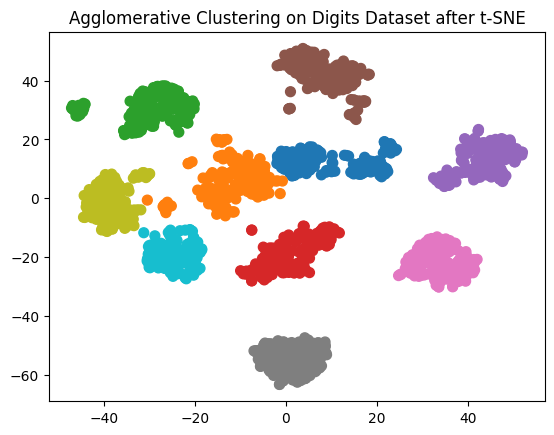

In [29]:
#Question 48
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE
from sklearn.cluster import AgglomerativeClustering

digits = load_digits()
X = digits.data
tsne = TSNE(n_components=2, random_state=0)
X_tsne = tsne.fit_transform(X)
agg = AgglomerativeClustering(n_clusters=10)
labels = agg.fit_predict(X_tsne)

plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='tab10', s=50)
plt.title('Agglomerative Clustering on Digits Dataset after t-SNE')
plt.show()